# Importing Libraries

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import kagglehub

pd.set_option('display.max_columns', None)

# Downloading Dataset from Kaggle

In [ ]:
path = kagglehub.dataset_download("thedevastator/unlock-profits-with-e-commerce-sales-data")

In [ ]:
df = pd.read_csv(path+'/Amazon Sale Report.csv', index_col=0)

<ipython-input-26-9fcfdbadf56b>:1: DtypeWarning: Columns (23) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(path+'/Amazon Sale Report.csv', index_col=0)


# Exploratory  Analysis on **Amazon Sale Report**

In [ ]:
# Dataset Shape
df.shape

(128975, 23)

In [ ]:
# Dataset Columns
df.columns

Index(['Order ID', 'Date', 'Status', 'Fulfilment', 'Sales Channel ',
       'ship-service-level', 'Style', 'SKU', 'Category', 'Size', 'ASIN',
       'Courier Status', 'Qty', 'currency', 'Amount', 'ship-city',
       'ship-state', 'ship-postal-code', 'ship-country', 'promotion-ids',
       'B2B', 'fulfilled-by', 'Unnamed: 22'],
      dtype='object')

In [ ]:
# Dataset Head
df.head()

,Order ID,Date,Status,Fulfilment,Sales Channel,ship-service-level,Style,SKU,Category,Size,ASIN,Courier Status,Qty,currency,Amount,ship-city,ship-state,ship-postal-code,ship-country,promotion-ids,B2B,fulfilled-by,Unnamed: 22
index,,,,,,,,,,,,,,,,,,,,,,,
0,405-8078784-5731545,04-30-22,Cancelled,Merchant,Amazon.in,Standard,SET389,SET389-KR-NP-S,Set,S,B09KXVBD7Z,NaN,0,INR,647.62,MUMBAI,MAHARASHTRA,400081.0,IN,NaN,False,Easy Ship,NaN
1,171-9198151-1101146,04-30-22,Shipped - Delivered to Buyer,Merchant,Amazon.in,Standard,JNE3781,JNE3781-KR-XXXL,kurta,3XL,B09K3WFS32,Shipped,1,INR,406.00,BENGALURU,KARNATAKA,560085.0,IN,Amazon PLCC Free-Financing Universal Merchant ...,False,Easy Ship,NaN
2,404-0687676-7273146,04-30-22,Shipped,Amazon,Amazon.in,Expedited,JNE3371,JNE3371-KR-XL,kurta,XL,B07WV4JV4D,Shipped,1,INR,329.00,NAVI MUMBAI,MAHARASHTRA,410210.0,IN,IN Core Free Shipping 2015/04/08 23-48-5-108,True,NaN,NaN
3,403-9615377-8133951,04-30-22,Cancelled,Merchant,Amazon.in,Standard,J0341,J0341-DR-L,Western Dress,L,B099NRCT7B,NaN,0,INR,753.33,PUDUCHERRY,PUDUCHERRY,605008.0,IN,NaN,False,Easy Ship,NaN
4,407-1069790-7240320,04-30-22,Shipped,Amazon,Amazon.in,Expedited,JNE3671,JNE3671-TU-XXXL,Top,3XL,B098714BZP,Shipped,1,INR,574.00,CHENNAI,TAMIL NADU,600073.0,IN,NaN,False,NaN,NaN


In [ ]:
# Dataset Info
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 128975 entries, 0 to 128974
Data columns (total 23 columns):
 #   Column              Non-Null Count   Dtype  
---  ------              --------------   -----  
 0   Order ID            128975 non-null  object 
 1   Date                128975 non-null  object 
 2   Status              128975 non-null  object 
 3   Fulfilment          128975 non-null  object 
 4   Sales Channel       128975 non-null  object 
 5   ship-service-level  128975 non-null  object 
 6   Style               128975 non-null  object 
 7   SKU                 128975 non-null  object 
 8   Category            128975 non-null  object 
 9   Size                128975 non-null  object 
 10  ASIN                128975 non-null  object 
 11  Courier Status      122103 non-null  object 
 12  Qty                 128975 non-null  int64  
 13  currency            121180 non-null  object 
 14  Amount              121180 non-null  float64
 15  ship-city           128942 non-null  ob

In [ ]:
# Setting correct data types
df = df.convert_dtypes()

In [ ]:
# Set Date column format
df['Date'] = pd.to_datetime(df['Date'], format='%m-%d-%y', dayfirst=True)

In [ ]:
# Checking new data types
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 128975 entries, 0 to 128974
Data columns (total 23 columns):
 #   Column              Non-Null Count   Dtype         
---  ------              --------------   -----         
 0   Order ID            128975 non-null  string        
 1   Date                128975 non-null  datetime64[ns]
 2   Status              128975 non-null  string        
 3   Fulfilment          128975 non-null  string        
 4   Sales Channel       128975 non-null  string        
 5   ship-service-level  128975 non-null  string        
 6   Style               128975 non-null  string        
 7   SKU                 128975 non-null  string        
 8   Category            128975 non-null  string        
 9   Size                128975 non-null  string        
 10  ASIN                128975 non-null  string        
 11  Courier Status      122103 non-null  string        
 12  Qty                 128975 non-null  Int64         
 13  currency            121180 non-nul

In [ ]:
# Count of unique values
df.nunique().to_frame(name='Count of unique values')

,Count of unique values
Order ID,120378
Date,91
Status,13
Fulfilment,2
Sales Channel,2
ship-service-level,2
Style,1377
SKU,7195
Category,9
Size,11


In [ ]:
# Unique Values
df.apply(pd.unique).to_frame(name='Unique Values')

,Unique Values
Order ID,"[405-8078784-5731545, 171-9198151-1101146, 404..."
Date,"[2022-04-30T00:00:00.000000000, 2022-04-29T00:..."
Status,"[Cancelled, Shipped - Delivered to Buyer, Ship..."
Fulfilment,"[Merchant, Amazon]"
Sales Channel,"[Amazon.in, Non-Amazon]"
ship-service-level,"[Standard, Expedited]"
Style,"[SET389, JNE3781, JNE3371, J0341, JNE3671, SET..."
SKU,"[SET389-KR-NP-S, JNE3781-KR-XXXL, JNE3371-KR-X..."
Category,"[Set, kurta, Western Dress, Top, Ethnic Dress,..."
Size,"[S, 3XL, XL, L, XXL, XS, 6XL, M, 4XL, 5XL, Free]"


In [ ]:
# Missing Values Count
missing_count = df.isnull().sum()
missing_count[missing_count > 0].to_frame(name='Count of missing values')

,Count of missing values
Courier Status,6872
currency,7795
Amount,7795
ship-city,33
ship-state,33
ship-postal-code,33
ship-country,33
promotion-ids,49153
fulfilled-by,89698
Unnamed: 22,49050


In [ ]:
# Deriving relation between 'Status' and 'Courier Status' to handle missing values in 'Courier Status'
df[['Status', 'Courier Status']].drop_duplicates()

,Status,Courier Status
index,,
0,Cancelled,<NA>
1,Shipped - Delivered to Buyer,Shipped
2,Shipped,Shipped
8,Cancelled,Cancelled
116,Cancelled,Unshipped
244,Shipped - Returned to Seller,Shipped
433,Shipped - Rejected by Buyer,Shipped
937,Shipped,Unshipped
1615,Shipped,Cancelled


# Cleaning Dataset

In [ ]:
# Set Date column format
df['Date'] = pd.to_datetime(df['Date'], format='%m-%d-%y', dayfirst=True)

# Replace "<NA>" with np.nan
df.replace('<NA>', np.nan, inplace=True)

# Removing columns with too many missing values
columns_to_drop = ['Unnamed: 22', 'fulfilled-by', 'promotion-ids']
df.drop(columns=columns_to_drop, axis=1, inplace=True)

# Removing 'Currency' column due to having only one unique value (INR)
df.drop(['currency'], axis=1, inplace=True)

# Removing rows with missing shipping info due to small amount of them
df.dropna(subset=['ship-city', 'ship-state', 'ship-postal-code', 'ship-country'], inplace=True)

# Filling missing values in 'Amount' with the mean
df['Amount'].fillna(df['Amount'].mean(), inplace=True)  # Fill with mean

# Filling missing values in 'Courier Status' with the most frequent value associated with 'Status' when 'Status' is Cancelled
freq_value = df.loc[df['Status'] == 'Cancelled','Courier Status'].value_counts().idxmax()
df.loc[df['Status'] == 'Cancelled','Courier Status'] = df.loc[df['Status'] == 'Cancelled','Courier Status'].fillna(freq_value)

# Filling missing values in 'Courier Status' with "Shipped" when 'Status' is "Shipped - Returned to Seller" or "Shipped - Delivered to Buyer"
df.loc[(df['Status'] == 'Shipped - Returned to Seller') | (df['Status'] == 'Shipped - Delivered to Buyer'), 'Courier Status'] = df.loc[(df['Status'] == 'Shipped - Returned to Seller') | (df['Status'] == 'Shipped - Delivered to Buyer'), 'Courier Status'].fillna('Shipped')

<ipython-input-38-a785363b7477>:18: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['Amount'].fillna(df['Amount'].mean(), inplace=True)  # Fill with mean


In [ ]:
df.head()

,Order ID,Date,Status,Fulfilment,Sales Channel,ship-service-level,Style,SKU,Category,Size,ASIN,Courier Status,Qty,Amount,ship-city,ship-state,ship-postal-code,ship-country,B2B
index,,,,,,,,,,,,,,,,,,,
0,405-8078784-5731545,2022-04-30,Cancelled,Merchant,Amazon.in,Standard,SET389,SET389-KR-NP-S,Set,S,B09KXVBD7Z,Cancelled,0,647.62,MUMBAI,MAHARASHTRA,400081,IN,False
1,171-9198151-1101146,2022-04-30,Shipped - Delivered to Buyer,Merchant,Amazon.in,Standard,JNE3781,JNE3781-KR-XXXL,kurta,3XL,B09K3WFS32,Shipped,1,406.0,BENGALURU,KARNATAKA,560085,IN,False
2,404-0687676-7273146,2022-04-30,Shipped,Amazon,Amazon.in,Expedited,JNE3371,JNE3371-KR-XL,kurta,XL,B07WV4JV4D,Shipped,1,329.0,NAVI MUMBAI,MAHARASHTRA,410210,IN,True
3,403-9615377-8133951,2022-04-30,Cancelled,Merchant,Amazon.in,Standard,J0341,J0341-DR-L,Western Dress,L,B099NRCT7B,Cancelled,0,753.33,PUDUCHERRY,PUDUCHERRY,605008,IN,False
4,407-1069790-7240320,2022-04-30,Shipped,Amazon,Amazon.in,Expedited,JNE3671,JNE3671-TU-XXXL,Top,3XL,B098714BZP,Shipped,1,574.0,CHENNAI,TAMIL NADU,600073,IN,False


In [ ]:
# Missing Values Count
missing_count = df.isnull().sum()
missing_count[missing_count > 0].to_frame(name='Count of missing values')

,Count of missing values


In [ ]:
# Save Cleaned Dataset
df.to_csv('Cleaned Amazon Sale Report.csv', index=False)

## **MODEL**

MAE: 76736.00
RMSE: 114492.83


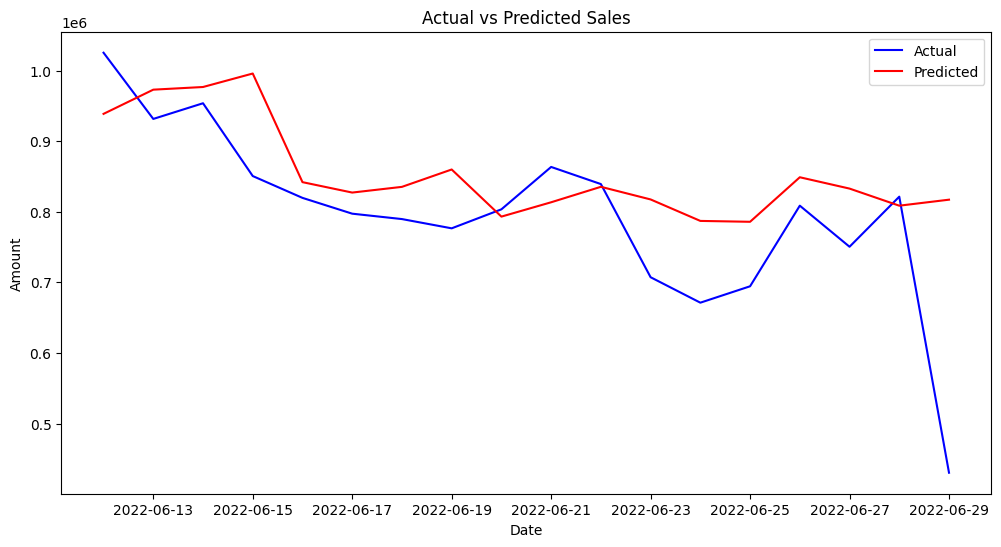


Forecast for Next 7 Days:
Day 1: Predicted Sales ₹792066.32
Day 2: Predicted Sales ₹830868.46
Day 3: Predicted Sales ₹859947.31
Day 4: Predicted Sales ₹863897.57
Day 5: Predicted Sales ₹870225.18
Day 6: Predicted Sales ₹924221.58
Day 7: Predicted Sales ₹989586.08


/usr/local/lib/python3.11/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but RandomForestRegressor was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but RandomForestRegressor was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but RandomForestRegressor was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but RandomForestRegressor was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but RandomForestRegressor was fitted with feature names
  warnings.warn(
/usr/local/lib/

In [ ]:
import pandas as pd
import numpy as np
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt

df_daily = df.groupby('Date')['Amount'].sum().reset_index()
# Convert Date column to datetime
df_daily['Date'] = pd.to_datetime(df_daily['Date'])

df_daily = df_daily.set_index('Date')

# Add day of week
df_daily['day_of_week'] = df_daily.index.dayofweek  # 0=Monday, 6=Sunday

# Add is_weekend feature (India: Saturday=5, Sunday=6)
df_daily['is_weekend'] = df_daily['day_of_week'].apply(lambda x: 1 if x >= 5 else 0)

# Create lag features
for lag in [1, 2, 3]:
    df_daily[f'lag_{lag}'] = df_daily['Amount'].shift(lag)

# Drop rows with missing values
df_model = df_daily.dropna()


X = df_model[['lag_1', 'lag_2', 'lag_3', 'day_of_week', 'is_weekend']]
y = df_model['Amount']

# Split data
X_train, X_test, y_train, y_test = train_test_split(X, y, shuffle=False, test_size=0.2)

# Train Random Forest
model = RandomForestRegressor(n_estimators=100, random_state=42)
model.fit(X_train, y_train)

# Predict and evaluate
y_pred = model.predict(X_test)
mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))

print(f"MAE: {mae:.2f}")
print(f"RMSE: {rmse:.2f}")

#Plot actual vs predicted
plt.figure(figsize=(12,6))
plt.plot(y_test.index, y_test.values, label='Actual', color='blue')
plt.plot(y_test.index, y_pred, label='Predicted', color='red')
plt.title('Actual vs Predicted Sales')
plt.xlabel('Date')
plt.ylabel('Amount')
plt.legend()
plt.show()

# Forecast next 7 days
last_lag_1 = df_daily['Amount'].iloc[-1]
last_lag_2 = df_daily['Amount'].iloc[-2]
last_lag_3 = df_daily['Amount'].iloc[-3]
last_day_of_week = df_daily['day_of_week'].iloc[-1]

future_preds = []
for i in range(7):
    next_day_of_week = (last_day_of_week + 1) % 7
    is_weekend = 1 if next_day_of_week >= 5 else 0
    X_new = [[last_lag_1, last_lag_2, last_lag_3, next_day_of_week, is_weekend]]
    y_new_pred = model.predict(X_new)[0]
    future_preds.append(y_new_pred)

    # Update lags and day
    last_lag_3 = last_lag_2
    last_lag_2 = last_lag_1
    last_lag_1 = y_new_pred
    last_day_of_week = next_day_of_week

print("\nForecast for Next 7 Days:")
for day, pred in enumerate(future_preds, 1):
    print(f"Day {day}: Predicted Sales ₹{pred:.2f}")




# **MODEL#2**

MAE: 56041.98
RMSE: 95552.73


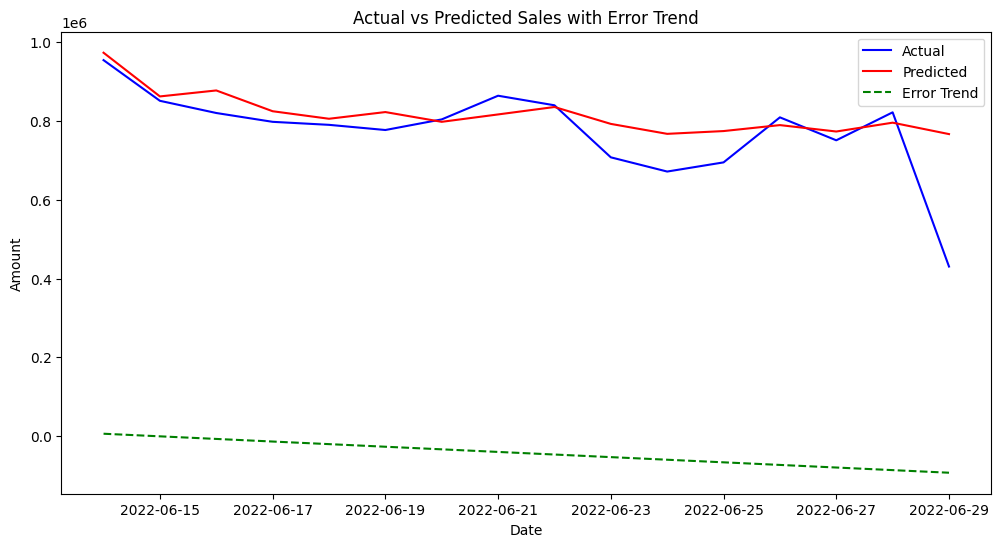


Error Analysis:
Mean Residual: -43065.09
Std of Residuals: 88095.23
Max Overprediction: -335844.33
Max Underprediction: 47443.24

Simple Forecast for Next 7 Days:
Day 1: ₹769859.58 ± 88095.23
Day 2: ₹766817.21 ± 88095.23
Day 3: ₹773867.40 ± 88095.23
Day 4: ₹789851.66 ± 88095.23
Day 5: ₹772750.35 ± 88095.23
Day 6: ₹773280.61 ± 88095.23
Day 7: ₹773842.20 ± 88095.23


In [ ]:
import pandas as pd
import numpy as np
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error
from sklearn.model_selection import TimeSeriesSplit
import matplotlib.pyplot as plt

df_daily = df.groupby('Date')['Amount'].sum().reset_index()
df_daily['Date'] = pd.to_datetime(df_daily['Date'])
df_daily = df_daily.set_index('Date')

df_daily['day_of_week'] = df_daily.index.dayofweek
df_daily['is_weekend'] = (df_daily['day_of_week'] >= 5).astype(int)

#most important lag features
df_daily['lag_1'] = df_daily['Amount'].shift(1)
df_daily['lag_7'] = df_daily['Amount'].shift(7)  # Weekly seasonality

# Simple moving average
df_daily['rolling_3_mean'] = df_daily['Amount'].rolling(window=3).mean()

# Drop rows with missing values
df_model = df_daily.dropna()

# Feature Selection - Only keep what's essential
X = df_model[['lag_1', 'lag_7', 'rolling_3_mean', 'day_of_week']]
y = df_model['Amount']

# Time-Based Split (last 20% as test)
test_size = int(len(X) * 0.2)
X_train, X_test = X.iloc[:-test_size], X.iloc[-test_size:]
y_train, y_test = y.iloc[:-test_size], y.iloc[-test_size:]

# Simple Model with Default Parameters
# Using fewer trees for faster training and less overfitting
model = RandomForestRegressor(n_estimators=50, random_state=42, n_jobs=-1)
model.fit(X_train, y_train)
# Evaluation
y_pred = model.predict(X_test)
mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))

print(f"MAE: {mae:.2f}")
print(f"RMSE: {rmse:.2f}")

# Plot with Trend Line
plt.figure(figsize=(12,6))
plt.plot(y_test.index, y_test.values, label='Actual', color='blue')
plt.plot(y_test.index, y_pred, label='Predicted', color='red')

# Add trend line to see systematic errors
z = np.polyfit(range(len(y_test)), y_test - y_pred, 1)
p = np.poly1d(z)
plt.plot(y_test.index, p(range(len(y_test))), 'g--', label='Error Trend')

plt.title('Actual vs Predicted Sales with Error Trend')
plt.xlabel('Date')
plt.ylabel('Amount')
plt.legend()
plt.show()

# Diagnostic Checks
residuals = y_test - y_pred
print(f"\nError Analysis:")
print(f"Mean Residual: {residuals.mean():.2f}")
print(f"Std of Residuals: {residuals.std():.2f}")
print(f"Max Overprediction: {residuals.min():.2f}")
print(f"Max Underprediction: {residuals.max():.2f}")

# Conservative Forecasting
def simple_forecast(model, last_values, days=7):
    forecasts = []
    current = last_values.copy()

    for _ in range(days):
        # Prepare input features
        X_pred = pd.DataFrame({
            'lag_1': [current['Amount']],
            'lag_7': [current['lag_7']],
            'rolling_3_mean': [current['rolling_3_mean']],
            'day_of_week': [(current['day_of_week'] + 1) % 7]
        })

        pred = model.predict(X_pred)[0]
        forecasts.append(pred)

        # Update state
        current['lag_7'] = current['lag_1'] if current['day_of_week'] == 6 else current['lag_7']
        current['lag_1'] = pred
        current['day_of_week'] = (current['day_of_week'] + 1) % 7
        current['rolling_3_mean'] = np.mean([current['lag_1'], current['lag_2'], current['lag_3']]) if 'lag_2' in current else current['rolling_3_mean']

    return forecasts

# Get last known values
last_known = {
    'Amount': df_model['Amount'].iloc[-1],
    'lag_1': df_model['lag_1'].iloc[-1],
    'lag_7': df_model['lag_7'].iloc[-1],
    'rolling_3_mean': df_model['rolling_3_mean'].iloc[-1],
    'day_of_week': df_model['day_of_week'].iloc[-1]
}

# Generate forecast
forecast_values = simple_forecast(model, last_known)

print("\nSimple Forecast for Next 7 Days:")
for i, pred in enumerate(forecast_values, 1):
    print(f"Day {i}: ₹{pred:.2f} ± {residuals.std():.2f}")

# **DEPLOYMENT**


In [ ]:
import joblib

# Save model
joblib.dump(model, 'sales_forecast_model.pkl')

feature_names = X.columns.tolist()
joblib.dump(feature_names, 'feature_names.pkl')


['feature_names.pkl']

In [ ]:
pip install streamlit


     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.3/44.3 kB 1.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.9/9.9 MB 60.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6.9/6.9 MB 90.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 79.1/79.1 kB 4.8 MB/s eta 0:00:00


In [ ]:
import streamlit as st
import pandas as pd
import numpy as np
import joblib
from datetime import datetime

# Load trained model and features
model = joblib.load('sales_forecast_model.pkl')
feature_names = joblib.load('feature_names.pkl')

st.title("📈 Sales Forecast App")
st.write("Enter the input features below:")

# Input fields
lag_1 = st.number_input('Sales 1 day ago (lag_1)', min_value=0)
lag_2 = st.number_input('Sales 2 days ago (lag_2)', min_value=0)
lag_3 = st.number_input('Sales 3 days ago (lag_3)', min_value=0)

date_input = st.date_input('Select Date', datetime.today())
day_of_week = date_input.weekday()
is_weekend = 1 if day_of_week in [5, 6] else 0
month = date_input.month

# Rolling mean (optional input)
rolling_mean_7 = st.number_input('Rolling mean (past 7 days)', min_value=0)

# Predict button
if st.button('Predict Sales'):
    # Create input dataframe
    input_data = pd.DataFrame([{
        'lag_1': lag_1,
        'lag_2': lag_2,
        'lag_3': lag_3,
        'day_of_week': day_of_week,
        'is_weekend': is_weekend,
        'month': month,
        'rolling_mean_7': rolling_mean_7
    }])[feature_names]  # Ensure correct order

    # Make prediction    prediction = model.predict(input_data)[0]

    st.success(f"📊 Predicted Sales: ₹{prediction:,.2f}")


2025-05-12 15:14:02.148 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2025-05-12 15:14:02.150 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2025-05-12 15:14:02.152 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2025-05-12 15:14:02.153 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2025-05-12 15:14:02.155 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2025-05-12 15:14:02.156 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2025-05-12 15:14:02.157 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2025-05-12 15:14:02.159 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bar

In [ ]:
from google.colab import files

# Download model and features file
files.download('sales_forecast_model.pkl')
files.download('feature_names.pkl')


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>